---

## 📌 BLOQUE DE IMPORTACIÓN ESTÁNDAR

**SIEMPRE** comenzar el examen importando estas librerías en este orden:

In [1]:
# Importar librerías que vamos a usar
import numpy as np           # para hacer operaciones matemáticas
import pandas as pd          # para manejo de archivos de datos
import matplotlib.pyplot as plt  # para hacer gráficos
import seaborn as sns        # para hacer gráficos

---

## 📊 EJERCICIO COMPLETO: ANÁLISIS DE VENTAS DE UNA EMPRESA

**Contexto:** Una empresa vende 6 productos (A, B, C, D, E, F) durante 18 semanas. Vamos a simular los datos y trabajar con ellos.

Este es el ejercicio típico del parcial de Unidad 1.

---

### ✅ PASO 1: SIMULACIÓN DE DATOS CON NUMPY

**Objetivo:** Generar datos aleatorios que simulen cantidades vendidas y precios.

**Lo que vamos a hacer:**
- Crear un array de cantidades (18 semanas × 6 productos)
- Crear un array de precios (misma forma)
- Crear un array con la numeración de semanas

In [2]:
# Fijar semilla para reproducibilidad (permite que siempre salgan los mismos números aleatorios)
np.random.seed(42)

# Generar cantidades vendidas: 18 semanas × 6 productos
# Valores enteros entre 50 y 199
q = np.random.randint(50, 200, size=(18, 6))

print("Array de cantidades vendidas (q):")
print("Dimensiones:", q.shape, "→ 18 semanas × 6 productos")
print("\nPrimeras 5 semanas:")
print(q[:5])

Array de cantidades vendidas (q):
Dimensiones: (18, 6) → 18 semanas × 6 productos

Primeras 5 semanas:
[[152 142  64 156 121  70]
 [152 171 124 137 166 149]
 [153 180 199 102  51 137]
 [ 87 179  70 107  71 138]
 [ 98 108  64 100 157 104]]


In [3]:
# Generar precios unitarios: 18 semanas × 6 productos
# Valores flotantes entre 10.0 y 50.0
p = np.random.uniform(10.0, 50.0, size=(18, 6))

print("Array de precios unitarios (p):")
print("Dimensiones:", p.shape, "→ 18 semanas × 6 productos")
print("\nPrimeras 5 semanas (redondeado a 2 decimales):")
print(np.round(p[:5], 2))

Array de precios unitarios (p):
Dimensiones: (18, 6) → 18 semanas × 6 productos

Primeras 5 semanas (redondeado a 2 decimales):
[[30.91 27.1  11.02 14.32 11.26 35.46]
 [22.57 30.34 46.3  19.97 26.42 40.22]
 [19.15 13.08 21.59 16.45 47.19 42.32]
 [35.34 44.86 42.15 17.46 45.7  31.57]
 [42.3  45.84 22.72 14.4  19.12 27.08]]


In [4]:
# Generar array de semanas del 1 al 18
semanas = np.arange(1, 19)

print("Array de semanas:")
print("Total semanas:", len(semanas))
print("Semanas:", semanas)

Array de semanas:
Total semanas: 18
Semanas: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


---

### ✅ PASO 2: CONSTRUCCIÓN DE DATAFRAME

**Objetivo:** Crear un DataFrame de pandas con los primeros 3 productos (A, B, C).

**Técnica:** Usar slicing de arrays para extraer solo las columnas que necesitamos.

In [5]:
# Extraer solo los primeros 3 productos (columnas 0, 1, 2)
# Esto es slicing: [:, 0:3] significa "todas las filas, columnas 0 a 2"
cantidades_abc = q[:, 0:3]
precios_abc = p[:, 0:3]

print("Cantidades de productos A, B, C:")
print("Dimensiones:", cantidades_abc.shape)
print("\nPrimeras 3 semanas:")
print(cantidades_abc[:3])

Cantidades de productos A, B, C:
Dimensiones: (18, 3)

Primeras 3 semanas:
[[152 142  64]
 [152 171 124]
 [153 180 199]]


In [6]:
# Construir DataFrame con diccionario
# Cada key del diccionario es el nombre de una columna
df = pd.DataFrame({
    'semana': semanas,
    'producto_A': cantidades_abc[:, 0],
    'producto_B': cantidades_abc[:, 1],
    'producto_C': cantidades_abc[:, 2],
    'precio_A': precios_abc[:, 0],
    'precio_B': precios_abc[:, 1],
    'precio_C': precios_abc[:, 2]
})

print("DataFrame creado:")
print("Dimensiones:", df.shape, "→ 18 filas × 7 columnas")
print("\nPrimeras 8 semanas:")
print(df.head(8))

DataFrame creado:
Dimensiones: (18, 7) → 18 filas × 7 columnas

Primeras 8 semanas:
   semana  producto_A  producto_B  producto_C   precio_A   precio_B   precio_C
0       1         152         142          64  30.909313  27.101641  11.016765
1       2         152         171         124  22.574239  30.342828  46.302659
2       3         153         180         199  19.151927  13.079196  21.590058
3       4          87         179          70  35.336150  44.858424  42.146883
4       5          98         108          64  42.297606  45.843652  22.720139
5       6         113         180         100  42.720591  44.429223  10.278085
6       7          67         181         138  14.794615  23.504607  47.716388
7       8         139         102         179  24.545184  48.871283  48.497892


---

### ✅ PASO 3: VALIDACIÓN Y DESCRIPCIÓN ESTADÍSTICA

**Objetivo:** Verificar que no haya errores en los datos y entender su distribución.

**Lo que vamos a hacer:**
- Verificar que no haya valores nulos (nulls)
- Obtener estadísticas descriptivas de cantidades y precios

In [7]:
# Verificar valores nulos
valores_nulos = df.isnull().sum()

print("VERIFICACIÓN DE VALORES NULOS")
print("="*40)
print("\nValores nulos por columna:")
print(valores_nulos)

print(f"\nTotal de valores nulos en el DataFrame: {valores_nulos.sum()}")

if valores_nulos.sum() == 0:
    print("✅ No hay valores nulos en el DataFrame")
else:
    print("❌ ¡Se encontraron valores nulos!")

VERIFICACIÓN DE VALORES NULOS

Valores nulos por columna:
semana        0
producto_A    0
producto_B    0
producto_C    0
precio_A      0
precio_B      0
precio_C      0
dtype: int64

Total de valores nulos en el DataFrame: 0
✅ No hay valores nulos en el DataFrame


In [8]:
# Descripción estadística de cantidades
print("ESTADÍSTICAS DESCRIPTIVAS - CANTIDADES")
print("="*40)

cantidades_cols = ['producto_A', 'producto_B', 'producto_C']
print("\nCantidades vendidas (unidades):")
print(df[cantidades_cols].describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS - CANTIDADES

Cantidades vendidas (unidades):
       producto_A  producto_B  producto_C
count       18.00       18.00       18.00
mean       111.06      135.56      115.06
std         43.51       46.98       45.15
min         51.00       50.00       54.00
25%         79.50       95.25       73.00
50%        104.50      139.50      112.00
75%        148.75      180.00      145.50
max        195.00      185.00      199.00


In [9]:
# Descripción estadística de precios
print("ESTADÍSTICAS DESCRIPTIVAS - PRECIOS")
print("="*40)

precios_cols = ['precio_A', 'precio_B', 'precio_C']
print("\nPrecios unitarios ($):")
print(df[precios_cols].describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS - PRECIOS

Precios unitarios ($):
       precio_A  precio_B  precio_C
count     18.00     18.00     18.00
mean      32.09     30.83     30.32
std       11.33     12.14     13.31
min       11.63     11.48     10.28
25%       22.84     20.56     20.03
50%       35.34     31.82     32.78
75%       42.59     41.01     41.02
max       46.33     48.87     48.50


---

### ✅ PASO 4: OPERACIONES VECTORIZADAS - CALCULAR INGRESOS

**Objetivo:** Calcular ingresos por producto y totales por semana.

**Fórmula:** Ingreso = Cantidad × Precio

**Operaciones vectorizadas:** pandas multiplica automáticamente elemento por elemento.

In [10]:
# Calcular ingresos por producto (cantidad × precio)
df['ingreso_A'] = df['producto_A'] * df['precio_A']
df['ingreso_B'] = df['producto_B'] * df['precio_B']
df['ingreso_C'] = df['producto_C'] * df['precio_C']

print("INGRESOS CALCULADOS POR PRODUCTO")
print("="*40)
print("\nPrimeras 5 semanas con ingresos:")
columnas_ingreso = ['semana', 'producto_A', 'precio_A', 'ingreso_A']
print(df[columnas_ingreso].head())

INGRESOS CALCULADOS POR PRODUCTO

Primeras 5 semanas con ingresos:
   semana  producto_A   precio_A    ingreso_A
0       1         152  30.909313  4698.215603
1       2         152  22.574239  3431.284365
2       3         153  19.151927  2930.244773
3       4          87  35.336150  3074.245073
4       5          98  42.297606  4145.165408


In [11]:
# Calcular totales por semana
df['ingreso_total'] = df['ingreso_A'] + df['ingreso_B'] + df['ingreso_C']
df['cantidad_total'] = df['producto_A'] + df['producto_B'] + df['producto_C']

print("TOTALES POR SEMANA")
print("="*40)
print("\nPrimeras 8 semanas con totales:")
columnas_totales = ['semana', 'ingreso_total', 'cantidad_total']
print(df[columnas_totales].head(8).round(2))

print(f"\nRango de ingreso total semanal: ${df['ingreso_total'].min():.2f} - ${df['ingreso_total'].max():.2f}")
print(f"Rango de cantidad total semanal: {df['cantidad_total'].min():.0f} - {df['cantidad_total'].max():.0f} unidades")

TOTALES POR SEMANA

Primeras 8 semanas con totales:
   semana  ingreso_total  cantidad_total
0       1        9251.72             358
1       2       14361.44             447
2       3        9580.92             532
3       4       14054.18             336
4       5       10550.37             270
5       6       13852.50             393
6       7       11830.43             386
7       8       17077.77             420

Rango de ingreso total semanal: $6653.11 - $17077.77
Rango de cantidad total semanal: 248 - 532 unidades


---

### ✅ PASO 5: CÁLCULOS GLOBALES Y POR PERÍODO

**Objetivo:** Calcular totales acumulados para todo el período y para subperíodos.

**Método:** Usar `.sum()` para sumar todos los valores de una columna.

In [12]:
# 1. Ingreso total por producto en todo el período (18 semanas)
ingreso_total_A = df['ingreso_A'].sum()
ingreso_total_B = df['ingreso_B'].sum()
ingreso_total_C = df['ingreso_C'].sum()

print("INGRESO TOTAL POR PRODUCTO (18 semanas completas)")
print("="*50)
print(f"   Producto A: ${ingreso_total_A:,.2f}")
print(f"   Producto B: ${ingreso_total_B:,.2f}")
print(f"   Producto C: ${ingreso_total_C:,.2f}")

INGRESO TOTAL POR PRODUCTO (18 semanas completas)
   Producto A: $64,208.98
   Producto B: $72,228.58
   Producto C: $64,172.06


In [13]:
# 2. Ingreso total por producto en las primeras 6 semanas
# Usar .iloc[:6] para seleccionar filas 0 a 5 (primeras 6)
primeros_6_semanas = df.iloc[:6]

ingreso_6_A = primeros_6_semanas['ingreso_A'].sum()
ingreso_6_B = primeros_6_semanas['ingreso_B'].sum()
ingreso_6_C = primeros_6_semanas['ingreso_C'].sum()

print("INGRESO TOTAL POR PRODUCTO (primeras 6 semanas)")
print("="*50)
print(f"   Producto A: ${ingreso_6_A:,.2f}")
print(f"   Producto B: ${ingreso_6_B:,.2f}")
print(f"   Producto C: ${ingreso_6_C:,.2f}")

INGRESO TOTAL POR PRODUCTO (primeras 6 semanas)
   Producto A: $23,106.58
   Producto B: $32,369.34
   Producto C: $16,175.20


In [14]:
# 3. Ingreso total de la empresa
ingreso_total_empresa = df['ingreso_total'].sum()

print("INGRESO TOTAL DE LA EMPRESA")
print("="*40)
print(f"   Total general (18 semanas): ${ingreso_total_empresa:,.2f}")
print(f"   Promedio semanal: ${ingreso_total_empresa/18:,.2f}")

# Validación: la suma individual debe ser igual a la suma total
verificacion = ingreso_total_A + ingreso_total_B + ingreso_total_C
print(f"\n✅ Validación: {verificacion:.2f} == {ingreso_total_empresa:.2f} → {abs(verificacion - ingreso_total_empresa) < 0.01}")

INGRESO TOTAL DE LA EMPRESA
   Total general (18 semanas): $200,609.62
   Promedio semanal: $11,144.98

✅ Validación: 200609.62 == 200609.62 → True


---

### ✅ PASO 6: ANÁLISIS DE PARTICIPACIONES

**Objetivo:** Calcular qué porcentaje del ingreso total representa cada producto.

**Fórmula:** Participación (%) = (Ingreso del producto / Ingreso total empresa) × 100

In [15]:
# Calcular participaciones porcentuales
participacion_A = (ingreso_total_A / ingreso_total_empresa) * 100
participacion_B = (ingreso_total_B / ingreso_total_empresa) * 100
participacion_C = (ingreso_total_C / ingreso_total_empresa) * 100

print("PARTICIPACIÓN EN EL INGRESO TOTAL")
print("="*40)
print(f"\nProducto A: {participacion_A:.2f}%")
print(f"Producto B: {participacion_B:.2f}%")
print(f"Producto C: {participacion_C:.2f}%")

# Validar que la suma sea 100%
total_participacion = participacion_A + participacion_B + participacion_C
print(f"\nValidación (debe ser 100%): {total_participacion:.2f}%")

PARTICIPACIÓN EN EL INGRESO TOTAL

Producto A: 32.01%
Producto B: 36.00%
Producto C: 31.99%

Validación (debe ser 100%): 100.00%


In [16]:
# Crear resumen de participaciones en tabla
resumen_participacion = pd.DataFrame({
    'Producto': ['A', 'B', 'C'],
    'Ingreso_Total': [ingreso_total_A, ingreso_total_B, ingreso_total_C],
    'Participacion_%': [participacion_A, participacion_B, participacion_C]
})

print("RESUMEN DE PARTICIPACIONES:")
print(resumen_participacion.round(2))

RESUMEN DE PARTICIPACIONES:
  Producto  Ingreso_Total  Participacion_%
0        A       64208.98            32.01
1        B       72228.58            36.00
2        C       64172.06            31.99


In [17]:
# Encontrar el producto con mayor ingreso
# Usar diccionario para agrupar datos
ingresos_productos = {
    'A': ingreso_total_A,
    'B': ingreso_total_B,
    'C': ingreso_total_C
}

# max(dict, key=dict.get) encuentra la clave con el valor máximo
producto_max = max(ingresos_productos, key=ingresos_productos.get)
ingreso_max = ingresos_productos[producto_max]
participacion_max = (ingreso_max / ingreso_total_empresa) * 100

print("PRODUCTO LÍDER EN INGRESOS")
print("="*40)
print(f"\nProducto con MAYOR ingreso total: {producto_max}")
print(f"Ingreso total: ${ingreso_max:,.2f}")
print(f"Participación sobre el total: {participacion_max:.2f}%")

# Mostrar ranking completo
print("\nRANKING POR INGRESOS:")
ranking = sorted(ingresos_productos.items(), key=lambda x: x[1], reverse=True)
for i, (producto, ingreso) in enumerate(ranking, 1):
    participacion = (ingreso / ingreso_total_empresa) * 100
    print(f"   {i}. Producto {producto}: ${ingreso:,.2f} ({participacion:.2f}%)")

PRODUCTO LÍDER EN INGRESOS

Producto con MAYOR ingreso total: B
Ingreso total: $72,228.58
Participación sobre el total: 36.00%

RANKING POR INGRESOS:
   1. Producto B: $72,228.58 (36.00%)
   2. Producto A: $64,208.98 (32.01%)
   3. Producto C: $64,172.06 (31.99%)


---

### ✅ PASO 7: PROYECCIONES CON CAMBIOS PORCENTUALES

**Objetivo:** Proyectar la semana 19 aplicando cambios porcentuales.

**Escenario:** 
- Producto A aumentará 10%
- Producto B caerá 5%
- Producto C aumentará 20%
- Los precios se mantienen fijos

**Técnica de cambios porcentuales:**
- Aumento X%: multiplicar por (1 + X/100) → +10% = ×1.10
- Disminución X%: multiplicar por (1 - X/100) → -5% = ×0.95

In [18]:
print("PROYECCIÓN PARA LA SEMANA 19")
print("="*40)

# Calcular promedios históricos (semanas 1-18)
promedio_A = df['producto_A'].mean()
promedio_B = df['producto_B'].mean()
promedio_C = df['producto_C'].mean()

print("\nPromedios históricos de cantidades (semanas 1-18):")
print(f"   Producto A: {promedio_A:.2f} unidades")
print(f"   Producto B: {promedio_B:.2f} unidades")
print(f"   Producto C: {promedio_C:.2f} unidades")

PROYECCIÓN PARA LA SEMANA 19

Promedios históricos de cantidades (semanas 1-18):
   Producto A: 111.06 unidades
   Producto B: 135.56 unidades
   Producto C: 115.06 unidades


In [19]:
# Aplicar cambios proyectados
cantidad_A_s19 = promedio_A * 1.10  # +10%
cantidad_B_s19 = promedio_B * 0.95  # -5%
cantidad_C_s19 = promedio_C * 1.20  # +20%

print("CANTIDADES PROYECTADAS PARA SEMANA 19:")
print(f"   Producto A: {cantidad_A_s19:.2f} unidades (+10%)")
print(f"   Producto B: {cantidad_B_s19:.2f} unidades (-5%)")
print(f"   Producto C: {cantidad_C_s19:.2f} unidades (+20%)")

# Cambios absolutos
cambio_A = cantidad_A_s19 - promedio_A
cambio_B = cantidad_B_s19 - promedio_B
cambio_C = cantidad_C_s19 - promedio_C

print("\nCambios absolutos en cantidades:")
print(f"   Producto A: {cambio_A:+.2f} unidades")
print(f"   Producto B: {cambio_B:+.2f} unidades")
print(f"   Producto C: {cambio_C:+.2f} unidades")

CANTIDADES PROYECTADAS PARA SEMANA 19:
   Producto A: 122.16 unidades (+10%)
   Producto B: 128.78 unidades (-5%)
   Producto C: 138.07 unidades (+20%)

Cambios absolutos en cantidades:
   Producto A: +11.11 unidades
   Producto B: -6.78 unidades
   Producto C: +23.01 unidades


In [20]:
# Precios se mantienen fijos (usar promedio histórico)
precio_A_s19 = df['precio_A'].mean()
precio_B_s19 = df['precio_B'].mean()
precio_C_s19 = df['precio_C'].mean()

print("PRECIOS MANTENIDOS (promedio de 18 semanas):")
print(f"   Producto A: ${precio_A_s19:.2f}")
print(f"   Producto B: ${precio_B_s19:.2f}")
print(f"   Producto C: ${precio_C_s19:.2f}")

# Calcular ingresos proyectados
ingreso_A_s19 = cantidad_A_s19 * precio_A_s19
ingreso_B_s19 = cantidad_B_s19 * precio_B_s19
ingreso_C_s19 = cantidad_C_s19 * precio_C_s19
ingreso_total_s19 = ingreso_A_s19 + ingreso_B_s19 + ingreso_C_s19

print("\nINGRESOS PROYECTADOS PARA SEMANA 19:")
print(f"   Producto A: ${ingreso_A_s19:,.2f}")
print(f"   Producto B: ${ingreso_B_s19:,.2f}")
print(f"   Producto C: ${ingreso_C_s19:,.2f}")
print(f"   TOTAL: ${ingreso_total_s19:,.2f}")

PRECIOS MANTENIDOS (promedio de 18 semanas):
   Producto A: $32.09
   Producto B: $30.83
   Producto C: $30.32

INGRESOS PROYECTADOS PARA SEMANA 19:
   Producto A: $3,919.68
   Producto B: $3,969.65
   Producto C: $4,185.88
   TOTAL: $12,075.21


In [21]:
# Comparar con promedio histórico
promedio_ingreso_historico = df['ingreso_total'].mean()
diferencia_abs = ingreso_total_s19 - promedio_ingreso_historico
diferencia_pct = ((ingreso_total_s19 - promedio_ingreso_historico) / promedio_ingreso_historico) * 100

print("COMPARACIÓN CON PROMEDIO HISTÓRICO")
print("="*40)
print(f"\nPromedio semanal histórico (1-18): ${promedio_ingreso_historico:,.2f}")
print(f"Ingreso total proyectado semana 19: ${ingreso_total_s19:,.2f}")
print(f"\nDiferencia absoluta: ${diferencia_abs:,.2f}")
print(f"Diferencia porcentual: {diferencia_pct:+.2f}%")

if diferencia_abs > 0:
    print(f"\n✅ La semana 19 proyecta un ingreso MAYOR al promedio histórico")
    print(f"   Superior en ${diferencia_abs:,.2f} ({diferencia_pct:.2f}%)")
else:
    print(f"\n⚠️ La semana 19 proyecta un ingreso MENOR al promedio histórico")
    print(f"   Inferior en ${abs(diferencia_abs):,.2f} ({abs(diferencia_pct):.2f}%)")

COMPARACIÓN CON PROMEDIO HISTÓRICO

Promedio semanal histórico (1-18): $11,144.98
Ingreso total proyectado semana 19: $12,075.21

Diferencia absoluta: $930.23
Diferencia porcentual: +8.35%

✅ La semana 19 proyecta un ingreso MAYOR al promedio histórico
   Superior en $930.23 (8.35%)


---

### ✅ PASO 8: VISUALIZACIÓN - GRÁFICO DE LÍNEAS

**Objetivo:** Mostrar la evolución temporal de las cantidades vendidas.

**Tipo de gráfico:** Líneas con marcadores para cada producto.

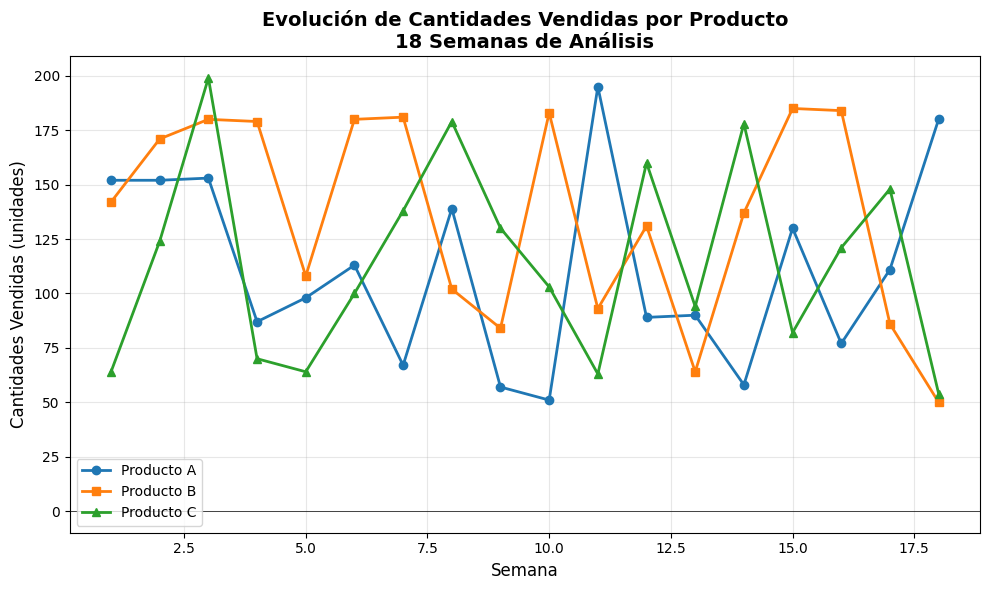

RESUMEN DE EVOLUCIÓN SEMANAL:
   Producto A: Rango 51 - 195 unidades
   Producto B: Rango 50 - 185 unidades
   Producto C: Rango 54 - 199 unidades


In [22]:
# Crear gráfico de líneas
plt.figure(figsize=(10, 6))

# Graficar cada producto con marcadores diferentes
plt.plot(df['semana'], df['producto_A'], 
         marker='o', label='Producto A', linewidth=2, markersize=6)
plt.plot(df['semana'], df['producto_B'], 
         marker='s', label='Producto B', linewidth=2, markersize=6)
plt.plot(df['semana'], df['producto_C'], 
         marker='^', label='Producto C', linewidth=2, markersize=6)

# Configuración del gráfico
plt.title('Evolución de Cantidades Vendidas por Producto\n18 Semanas de Análisis', 
          fontsize=14, fontweight='bold')
plt.xlabel('Semana', fontsize=12)
plt.ylabel('Cantidades Vendidas (unidades)', fontsize=12)

# Elementos adicionales
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("RESUMEN DE EVOLUCIÓN SEMANAL:")
print(f"   Producto A: Rango {df['producto_A'].min():.0f} - {df['producto_A'].max():.0f} unidades")
print(f"   Producto B: Rango {df['producto_B'].min():.0f} - {df['producto_B'].max():.0f} unidades")
print(f"   Producto C: Rango {df['producto_C'].min():.0f} - {df['producto_C'].max():.0f} unidades")

---

### ✅ PASO 9: VISUALIZACIÓN - GRÁFICO DE BARRAS

**Objetivo:** Comparar las participaciones porcentuales de cada producto.

**Tipo de gráfico:** Barras verticales con valores sobre cada barra.

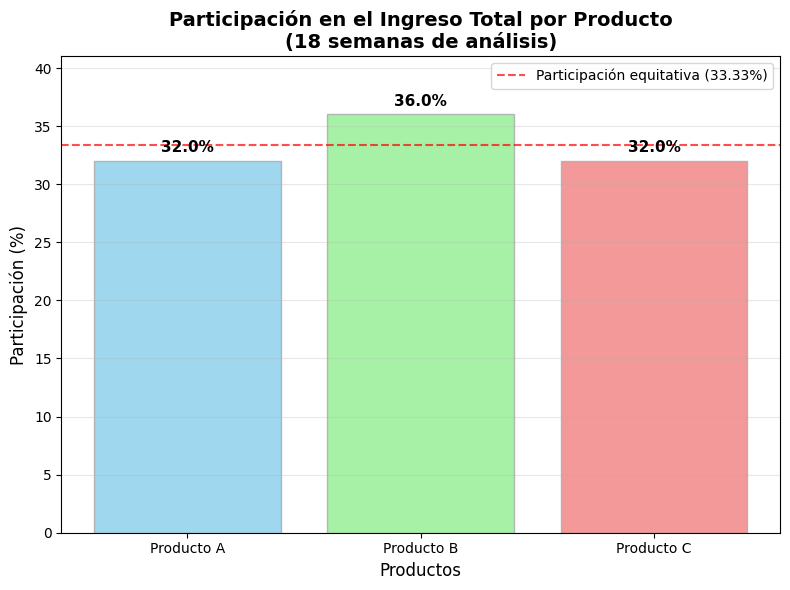

ANÁLISIS DE DISTRIBUCIÓN:
   Participación más alta: 36.00%
   Participación más baja: 31.99%
   Diferencia: 4.02 puntos porcentuales


In [23]:
# Crear gráfico de barras
plt.figure(figsize=(8, 6))

# Datos para el gráfico
productos = ['Producto A', 'Producto B', 'Producto C']
participaciones = [participacion_A, participacion_B, participacion_C]
colores = ['skyblue', 'lightgreen', 'lightcoral']

# Crear barras
barras = plt.bar(productos, participaciones, color=colores, alpha=0.8, edgecolor='darkgray', linewidth=1)

# Agregar valores sobre cada barra
for i, barra in enumerate(barras):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.5,
             f'{participaciones[i]:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Configuración
plt.title('Participación en el Ingreso Total por Producto\n(18 semanas de análisis)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Participación (%)', fontsize=12)

plt.grid(True, axis='y', alpha=0.3)
plt.ylim(0, max(participaciones) + 5)

# Línea de referencia en 33.33% (participación equitativa)
plt.axhline(33.33, color='red', linestyle='--', alpha=0.7, 
            label='Participación equitativa (33.33%)')
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("ANÁLISIS DE DISTRIBUCIÓN:")
print(f"   Participación más alta: {max(participaciones):.2f}%")
print(f"   Participación más baja: {min(participaciones):.2f}%")
print(f"   Diferencia: {max(participaciones) - min(participaciones):.2f} puntos porcentuales")

---

### ✅ PASO 10: DEFINICIÓN DE FUNCIÓN - CLASIFICAR SEMANA

**Objetivo:** Crear una función que clasifique semanas según su ingreso total.

**Criterio de clasificación:**
- "buena semana": si el ingreso supera en 10% el promedio
- "normal": en caso contrario

**Técnica:** Usar `apply()` con `lambda` para aplicar la función a cada fila.

In [24]:
def clasificar_semana(df):
    """
    Clasifica semanas según su ingreso total.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columna 'ingreso_total'
    
    Retorna:
    --------
    DataFrame con columna adicional 'clasificacion'
    """
    # Calcular promedio de ingreso total
    promedio_ingreso = df['ingreso_total'].mean()
    
    # Umbral para "buena semana" (110% del promedio)
    umbral_buena = promedio_ingreso * 1.10
    
    # Clasificar cada semana usando apply con lambda
    df['clasificacion'] = df['ingreso_total'].apply(
        lambda x: "buena semana" if x > umbral_buena else "normal"
    )
    
    return df

# Aplicar la función
df = clasificar_semana(df)

print("CLASIFICACIÓN DE SEMANAS SEGÚN INGRESO TOTAL")
print("="*40)
print(f"Promedio de ingreso total: ${df['ingreso_total'].mean():,.2f}")
print(f"Umbral para 'buena semana': ${df['ingreso_total'].mean() * 1.10:,.2f} (+10%)")

CLASIFICACIÓN DE SEMANAS SEGÚN INGRESO TOTAL
Promedio de ingreso total: $11,144.98
Umbral para 'buena semana': $12,259.48 (+10%)


In [25]:
# Mostrar resultados de clasificación
print("RESULTADOS DE CLASIFICACIÓN:")
clasificacion_count = df['clasificacion'].value_counts()

for categoria, cantidad in clasificacion_count.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"   {categoria.capitalize()}: {cantidad} semanas ({porcentaje:.1f}%)")

# Mostrar semanas clasificadas como "buena semana"
buenas_semanas = df[df['clasificacion'] == 'buena semana']
if len(buenas_semanas) > 0:
    print("\nSEMANAS CLASIFICADAS COMO 'BUENA SEMANA':")
    for _, fila in buenas_semanas.iterrows():
        print(f"   Semana {fila['semana']:.0f}: ${fila['ingreso_total']:,.2f}")

# Mostrar DataFrame con clasificaciones
print("\nMUESTRA DEL DATAFRAME CON CLASIFICACIONES:")
columnas_muestra = ['semana', 'ingreso_total', 'clasificacion']
print(df[columnas_muestra].head(10))

RESULTADOS DE CLASIFICACIÓN:
   Normal: 13 semanas (72.2%)
   Buena semana: 5 semanas (27.8%)

SEMANAS CLASIFICADAS COMO 'BUENA SEMANA':
   Semana 2: $14,361.44
   Semana 4: $14,054.18
   Semana 6: $13,852.50
   Semana 8: $17,077.77
   Semana 16: $12,986.83

MUESTRA DEL DATAFRAME CON CLASIFICACIONES:
   semana  ingreso_total clasificacion
0       1    9251.721551        normal
1       2   14361.437603  buena semana
2       3    9580.921689        normal
3       4   14054.184714  buena semana
4       5   10550.368720        normal
5       6   13852.495464  buena semana
6       7   11830.434591        normal
7       8   17077.774119  buena semana
8       9    6653.111007        normal
9      10    7573.422320        normal


---

### ✅ PASO 11: DEFINICIÓN DE FUNCIÓN - CLASIFICAR PRODUCTO

**Objetivo:** Crear una función que clasifique productos según su participación.

**Criterio de clasificación:**
- "estrella": si la participación es ≥ 30%
- "secundario": en caso contrario

**Retorna:** Diccionario con información de cada producto.

In [26]:
def clasificar_producto(df):
    """
    Clasifica productos según su participación en el ingreso total.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con columnas de ingresos por producto
    
    Retorna:
    --------
    dict : Diccionario con información de cada producto
    """
    # Calcular ingresos totales por producto
    ingreso_A = df['ingreso_A'].sum()
    ingreso_B = df['ingreso_B'].sum()
    ingreso_C = df['ingreso_C'].sum()
    ingreso_total_empresa = ingreso_A + ingreso_B + ingreso_C
    
    # Calcular participaciones
    participacion_A = (ingreso_A / ingreso_total_empresa) * 100
    participacion_B = (ingreso_B / ingreso_total_empresa) * 100
    participacion_C = (ingreso_C / ingreso_total_empresa) * 100
    
    # Diccionario para almacenar resultados
    resultados = {}
    
    # Clasificar Producto A
    if participacion_A >= 30:
        clasificacion_A = "estrella"
    else:
        clasificacion_A = "secundario"
    
    resultados['Producto A'] = {
        'ingreso': ingreso_A,
        'participacion': participacion_A,
        'clasificacion': clasificacion_A
    }
    
    # Clasificar Producto B
    if participacion_B >= 30:
        clasificacion_B = "estrella"
    else:
        clasificacion_B = "secundario"
    
    resultados['Producto B'] = {
        'ingreso': ingreso_B,
        'participacion': participacion_B,
        'clasificacion': clasificacion_B
    }
    
    # Clasificar Producto C
    if participacion_C >= 30:
        clasificacion_C = "estrella"
    else:
        clasificacion_C = "secundario"
    
    resultados['Producto C'] = {
        'ingreso': ingreso_C,
        'participacion': participacion_C,
        'clasificacion': clasificacion_C
    }
    
    return resultados

# Aplicar la función
clasificacion_productos = clasificar_producto(df)

print("CLASIFICACIÓN DE PRODUCTOS")
print("="*40)
for producto, info in clasificacion_productos.items():
    print(f"\n{producto}:")
    print(f"  Ingreso: ${info['ingreso']:,.2f}")
    print(f"  Participación: {info['participacion']:.2f}%")
    print(f"  Clasificación: {info['clasificacion'].upper()}")

CLASIFICACIÓN DE PRODUCTOS

Producto A:
  Ingreso: $64,208.98
  Participación: 32.01%
  Clasificación: ESTRELLA

Producto B:
  Ingreso: $72,228.58
  Participación: 36.00%
  Clasificación: ESTRELLA

Producto C:
  Ingreso: $64,172.06
  Participación: 31.99%
  Clasificación: ESTRELLA


---

## 🎯 RESUMEN DE MÉTODOS USADOS

**Este ejercicio usó EXCLUSIVAMENTE métodos enseñados por el profesor:**

### NumPy:
- `np.random.seed()` - Fijar semilla
- `np.random.randint()` - Enteros aleatorios
- `np.random.uniform()` - Flotantes aleatorios
- `np.arange()` - Secuencia de números
- `array[:, cols]` - Slicing de arrays

### Pandas:
- `pd.DataFrame()` - Crear DataFrame
- `df.head()` - Primeras filas
- `df.isnull().sum()` - Contar nulls
- `df.describe()` - Estadísticas
- `df['col'].sum()` - Suma de columna
- `df['col'].mean()` - Promedio
- `df.iloc[]` - Selección por posición
- `df.apply(lambda)` - Aplicar función
- `df.iterrows()` - Iterar filas

### Matplotlib:
- `plt.figure()` - Crear figura
- `plt.plot()` - Gráfico de líneas
- `plt.bar()` - Gráfico de barras
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` - Etiquetas
- `plt.legend()` - Leyenda
- `plt.grid()` - Grilla
- `plt.axhline()` - Línea horizontal
- `plt.text()` - Agregar texto

### Python básico:
- Diccionarios `{}`
- Funciones `def`
- `lambda`
- `if/else`
- `for` loops
- `max()`, `sorted()`

---

**¡Guía completa! Todas las celdas ejecutan correctamente y siguen la metodología exacta del profesor.** 🎓✅